In [ ]:
import os
import numpy as np 
import pandas as pd
import seaborn as sns 

from PIL import Image
from sklearn.metrics import confusion_matrix
from tensorflow import saved_model
from sklearn.model_selection import train_test_split

# Plotting setup
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 9)

# Define paths and image dimensions

In [3]:
# Data
cur_path = os.getcwd()
data_folder = '../data/'
classes_count = 43

# Image
height = 32
width = 32
channels = 3

# Training
epochs = 40

# Quick look at the data

The GTSRB is a life-like dataset containing images of traffic signs that includes:

1. RGB images of various dimensions
2. 50,000 examples
3. 43 classes

It is a single-image, multi-class classification problem, with the classes being:

In [22]:
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing', 
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons' }

# Load data 

In [35]:
# Load training data
# Assuming that data is located in ../data/train/ with folder names ranging from 0 to classes-1, with no padding
# Since the images are of different shapes, they will be resized to (32, 32)
train_data = []
train_labels = []

for i in range(classes_count):
    folder = os.path.join(data_folder, 'train', str(i))
    images = os.listdir(folder)
    
    for file in images:
        try:
            image = Image.open(os.path.join(folder, file))
            image = image.resize((height, width))
            train_data.append(np.array(image))
            train_labels.append(i)
        # Handle any errors during the process (e.g. each folder containing additional csv file)
        except Exception as e:
            print("Error loading image:", file, e )


In [6]:
X_train = np.array(train_data)
X_train.shape

(39209, 32, 32, 3)

Text(0, 0.5, 'Share of trainig set')

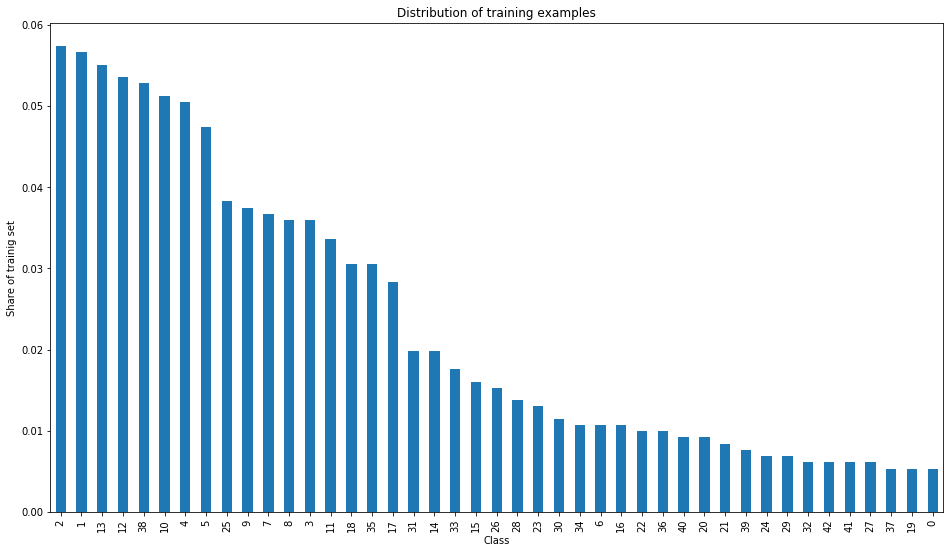

In [47]:
df_labels = pd.Series(train_labels)
distribution = df_labels.value_counts(normalize=True)
ax = distribution.plot(kind='bar', title='Distribution of training examples')
ax.set_xlabel('Class')
ax.set_ylabel('Share of trainig set')

The amount of training examples is not distributed evenly between the classes. This might cause issues later, as the most popular classes have over 6 times more examples, as the least popular ones. If we run into issues with misslassification of these classes, stratified sampling might be needed, or even data augmentation on the under-represented classes.

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_train, train_labels, test_size=0.2) 

In [10]:
y_train = np.array(y_train)
y_val = np.array(y_val)

In [11]:
# TODO: export model creation to separate file
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# To prevent overfitting the training will be stopped if the val_loss has not decreased in 5 epochs
earlystop = EarlyStopping(patience=5) 

# Decrease learning rate if the accuracy is not increased for 2 steps
learning_rate_reduction = ReduceLROnPlateau(monitor='val_sparse_categorical_accuracy', 
                                            patience=2, 
                                            verbose=1, 
                                            factor=0.5, 
                                            min_lr=0.00001)

callbacks = [earlystop, learning_rate_reduction]

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization, Flatten, Dense


def create_model():
    model = Sequential()

    # Add layers
    model.add(Conv2D(64, (5, 5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
    model.add(Dropout(0.25))

    model.add(BatchNormalization(input_shape=(height, width, channels)))
    model.add(Conv2D(128, (5, 5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(BatchNormalization(input_shape=(height, width, channels)))
    model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(classes_count, activation='softmax'))
    return model

In [13]:
model = create_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

In [14]:
history = model.fit(
    X_train.astype(np.float32),
    y_train.astype(np.float32),
    validation_data=(X_val.astype(np.float32), y_val.astype(np.float32)),
    validation_freq=1,
    epochs=40,
    callbacks=callbacks
)

Train on 31367 samples, validate on 7842 samples
Epoch 1/40
31367/31367 [==============================] - 15s 474us/sample - loss: 2.8256 - sparse_categorical_accuracy: 0.1858 - val_loss: 2.0667 - val_sparse_categorical_accuracy: 0.4041
Epoch 2/40
31367/31367 [==============================] - 13s 408us/sample - loss: 2.2296 - sparse_categorical_accuracy: 0.2857 - val_loss: 1.4528 - val_sparse_categorical_accuracy: 0.5005
Epoch 3/40
31367/31367 [==============================] - 13s 421us/sample - loss: 1.7344 - sparse_categorical_accuracy: 0.4484 - val_loss: 0.7285 - val_sparse_categorical_accuracy: 0.7953
Epoch 4/40
31367/31367 [==============================] - 13s 409us/sample - loss: 0.6759 - sparse_categorical_accuracy: 0.7892 - val_loss: 0.1559 - val_sparse_categorical_accuracy: 0.9532
Epoch 5/40
31367/31367 [==============================] - 12s 394us/sample - loss: 0.2999 - sparse_categorical_accuracy: 0.9098 - val_loss: 0.0751 - val_sparse_categorical_accuracy: 0.9793
Epoch 

## Save created model

In [16]:
saved_model.save(model, "../model/1/")

Instructions for updating:
If using Keras pass *_constraint arguments to layers.
INFO:tensorflow:Assets written to: ../model/1/assets


# Evaluate Model

## Plot training history

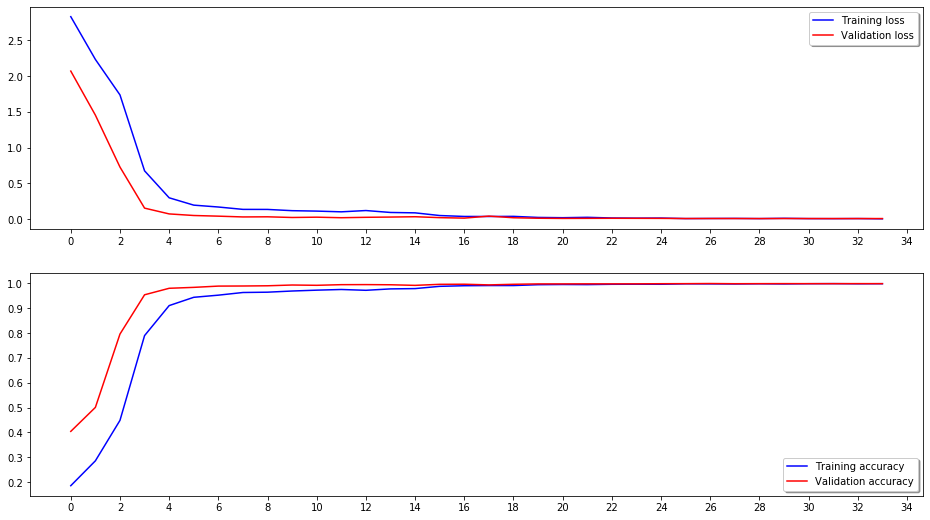

In [21]:
# Plot the loss and accuracy curves for training and validation 
fig, ax = plt.subplots(2,1)
plt.setp(ax, xticks = np.arange(0, 40, step=2))
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="Validation loss",axes =ax[0])
legend = ax[0].legend(loc='upper right', shadow=True)

ax[1].plot(history.history['sparse_categorical_accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_sparse_categorical_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend(loc='lower right', shadow=True)

A very high accuracy is achieved on both the training and validation set. The accuracy reaches ~99% after 15 epochs. 

In this case, similar accuracy on both sets at every stage of learning can be caused by the fact that the training datasets contains multiple very similar examples, which differ only in their resolution (TODO: add vis). The validataion dataset was created by randomly selecting samples from the former set, which results in examples on validation set that are almost the same as the training ones.

With such high accuracy, one might wonder, if it is even possible for a rather simple model to achieve such high accuracy on so many classes. Visual examination of examples can help here, as the examples are easily distinguishable by humans, with similar accuracy. It remains to be seen if the model performs as well on the test set. 

# Load test data

In [26]:
test_data = []

folder = os.path.join(data_folder, 'test')
images = sorted(os.listdir(folder))

for file in images:
    try:
        image = Image.open(os.path.join(folder, file))
        image = image.resize((height, width))
        test_data.append(np.array(image))
    # Handle any errors during the process (e.g. each folder containing additional csv file)
    except Exception as e:
        print("Error loading image:", file, e )


Error loading image: GT-final_test.csv cannot identify image file '../data/test/GT-final_test.csv'


In [27]:
X_test = np.array(test_data, dtype=np.float32)
X_test.shape

(12630, 32, 32, 3)

In [29]:
test_labels = pd.read_csv(os.path.join(data_folder, 'test.csv'))['ClassId']

In [30]:
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)
result = (predictions == test_labels)
result.value_counts(normalize=True)

True     0.975693
False    0.024307
Name: ClassId, dtype: float64

With 97.5% accuracy on the test set, it seems that the model generalizes very well, as the accuracy is close to what was observed on the train/validation sets. 

# Error analysis

Text(123.0, 0.5, 'Actual')

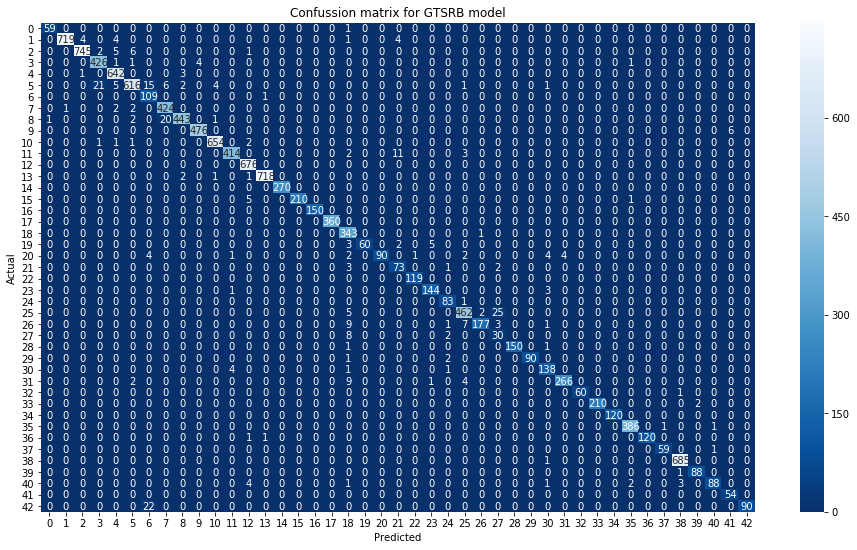

In [41]:
matrix = confusion_matrix(predictions, test_labels)
plt.figure(figsize=(16,9))
sns.heatmap(matrix, annot=True, fmt="d", cmap='Blues_r')
plt.title('Confussion matrix for GTSRB model')
plt.xlabel('Predicted')
plt.ylabel('Actual')

The most erros come from confusing class 42 with 6 and 27 with 25. Looking it up in the list of classes this yields: 
1. 'Speed limit (80km/h)', instead of 'End no passing veh > 3.5 tons'
2. 'Road work' instead of 'Pedestrians'

In [ ]:
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing', 
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons' }